Reference: https://github.com/ngchunlong279645/Capacitated-Vehicle-Routing-Problem-CVRP-

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp # python wrapper for constraint programming - Google’s internal solver engine C++
from math import radians, cos, sin, sqrt, atan2

In [2]:
# parameters
depot_lat, depot_lon = 4.4184, 114.0932
vehicles_df = pd.DataFrame({
    'vehicle_id': [0, 1, 2],
    'type': ['Type A', 'Type A', 'Type B'],
    'capacity_kg': [30, 30, 20],
    'cost_per_km': [1.20, 1.20, 1.50],
    'color': ['#1f77b4', '#ff7f0e', '#2ca02c']  # for plotting
})

In [3]:
# functions
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on the Earth.
    Haversine = "HALF-VERSED-SINE"
    """
    R = 6371  # Earth radius in kilometers
    # Radians are a unit of angular measure defined by the radius of a circle.
    # 1 Radian = 57.3°, equivalent to the angle subtended at the centre of a circle by an arc equal in length to the radius.
    # Radians are needed for sin() and trigonometric functions.
    dlat = radians(lat2 - lat1) # Δlat in radians
    dlon = radians(lon2 - lon1) # Δlon in radians
    # difference on the sphere — it is a DIMENSIONLESS number (0 to 1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    # angle (in radians) subtended at the center of the sphere
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c # ← real distance over the curved Earth
def create_data_model(
    demands,
    vehicles_df,
    distance_matrix
):
    """
    Pure function: returns OR-Tools data dict
    Parameters:
        locations: list of (lat, lon)
        demands: list of int
        vehicles_df: DataFrame with capacity_kg, cost_per_km
        distance_matrix: computed distance matrix
    """
    data = {
        'distance_matrix': distance_matrix,
        'demands': demands,
        'vehicle_capacities': vehicles_df['capacity_kg'].tolist(),
        'vehicle_costs_per_km': vehicles_df['cost_per_km'].tolist(),
        'vehicle_colors': vehicles_df['color'].tolist(),
        'vehicle_types': vehicles_df['type'].tolist(),
        'num_vehicles': len(vehicles_df),
        'depot': 0
    }
    return data
def make_distance_callback(data, manager):
    """
    Factory function that returns a callback with data & manager captured.
    This is how Google does it in ALL official examples.
    """
    def distance_callback(from_index, to_index):
        """Returns distance in meters (integer)"""
        from_node = manager.IndexToNode(from_index)
        to_node   = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]
    
    return distance_callback
def make_demand_callback(data, manager):
    """Factory: returns a unary callback that retrieves demand at a node."""
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data['demands'][from_node]
    return demand_callback
def nearest_neighbor_solution(data, locations):
    unvisited = set(range(1, len(locations)))  # customers 1 to n
    routes = []
    loads = []
    distances = []

    for vid in range(data['num_vehicles']):
        route = [0]           # start at depot
        current = 0
        load = 0
        dist = 0

        while unvisited:
            # Find feasible customers this vehicle can still serve
            candidates = [
                n for n in unvisited
                if load + data['demands'][n] <= data['vehicle_capacities'][vid]
            ]
            if not candidates:
                break  # vehicle full

            # Pick nearest
            dists = [data['distance_matrix'][current][n] for n in candidates]
            next_node = candidates[np.argmin(dists)]
            
            # Add to route
            route.append(next_node)
            dist += data['distance_matrix'][current][next_node]
            load += data['demands'][next_node]
            current = next_node
            unvisited.remove(next_node)

        # Return to depot
        if len(route) > 1:
            dist += data['distance_matrix'][current][0]
        route.append(0)

        routes.append(route)
        loads.append(load)
        distances.append(dist)

    return routes, distances, loads

# Creating the Data Model

In [4]:
# load customerData
df = pd.read_excel('customerData.xlsx')  # Columns: Customer, Latitude, Longitude, Demand
df

,CustomerID,Latitude,Longitude,Demand
0,1,4.3555,113.9777,5
1,2,4.3976,114.0049,8
2,3,4.3163,114.0764,3
3,4,4.3184,113.9932,6
4,5,4.4024,113.9896,5
5,6,4.4142,114.0127,8
6,7,4.4804,114.0734,3
7,8,4.3818,114.2034,6
8,9,4.4935,114.1828,5
9,10,4.4932,114.1322,8


In [5]:
locations = [(depot_lat, depot_lon)] + list(zip(df['Latitude'], df['Longitude']))
locations

[(4.4184, 114.0932),
 (4.3555, 113.9777),
 (4.3976, 114.0049),
 (4.3163, 114.0764),
 (4.3184, 113.9932),
 (4.4024, 113.9896),
 (4.4142, 114.0127),
 (4.4804, 114.0734),
 (4.3818, 114.2034),
 (4.4935, 114.1828),
 (4.4932, 114.1322)]

In [6]:
demands = [0] + list(df['Demand'])  # Depot demand = 0
demands

[0, 5, 8, 3, 6, 5, 8, 3, 6, 5, 8]

In [7]:
# Build distance matrix (in meters for greater precision and efficiency of OR-Tools)
n = len(locations)
distance_matrix = [[0] * n for _ in range(n)]
for i in range(n):
    for j in range(n):
        if i != j:
            distance_matrix[i][j] = int(haversine(*locations[i], *locations[j]) * 1000)
distance_matrix

[[0, 14590, 10058, 11504, 15702, 11622, 8936, 7235, 12877, 12976, 9373],
 [14590, 0, 5568, 11779, 4468, 5379, 7593, 17477, 25194, 27431, 22974],
 [10058, 5568, 0, 12023, 8901, 1778, 2038, 11934, 22077, 22420, 17668],
 [11504, 11779, 12023, 0, 9228, 13574, 12976, 18250, 15853, 22964, 20620],
 [15702, 4468, 8901, 9228, 0, 9348, 10869, 20088, 24348, 28652, 24804],
 [11622, 5379, 1778, 13574, 9348, 0, 2877, 12709, 23814, 23692, 18757],
 [8936, 7593, 2038, 12976, 10869, 2877, 0, 9973, 21447, 20816, 15895],
 [7235, 17477, 11934, 18250, 20088, 12709, 9973, 0, 18108, 12214, 6671],
 [12877, 25194, 22077, 15853, 24348, 23814, 21447, 18108, 0, 12628, 14688],
 [12976, 27431, 22420, 22964, 28652, 23692, 20816, 12214, 12628, 0, 5609],
 [9373, 22974, 17668, 20620, 24804, 18757, 15895, 6671, 14688, 5609, 0]]

In [8]:
# create the data model for OR-Tools which contains all problem data in VRP
data = create_data_model(demands, vehicles_df, distance_matrix)
data

{'distance_matrix': [[0,
   14590,
   10058,
   11504,
   15702,
   11622,
   8936,
   7235,
   12877,
   12976,
   9373],
  [14590, 0, 5568, 11779, 4468, 5379, 7593, 17477, 25194, 27431, 22974],
  [10058, 5568, 0, 12023, 8901, 1778, 2038, 11934, 22077, 22420, 17668],
  [11504, 11779, 12023, 0, 9228, 13574, 12976, 18250, 15853, 22964, 20620],
  [15702, 4468, 8901, 9228, 0, 9348, 10869, 20088, 24348, 28652, 24804],
  [11622, 5379, 1778, 13574, 9348, 0, 2877, 12709, 23814, 23692, 18757],
  [8936, 7593, 2038, 12976, 10869, 2877, 0, 9973, 21447, 20816, 15895],
  [7235, 17477, 11934, 18250, 20088, 12709, 9973, 0, 18108, 12214, 6671],
  [12877, 25194, 22077, 15853, 24348, 23814, 21447, 18108, 0, 12628, 14688],
  [12976, 27431, 22420, 22964, 28652, 23692, 20816, 12214, 12628, 0, 5609],
  [9373, 22974, 17668, 20620, 24804, 18757, 15895, 6671, 14688, 5609, 0]],
 'demands': [0, 5, 8, 3, 6, 5, 8, 3, 6, 5, 8],
 'vehicle_capacities': [30, 30, 20],
 'vehicle_costs_per_km': [1.2, 1.2, 1.5],
 'vehicle

# Constrained Programming

In [9]:
# Translate node numbers into OR-Tools’ internal indices
manager = pywrapcp.RoutingIndexManager(
    len(data['distance_matrix']), 
    data['num_vehicles'], 
    data['depot']
)
# The actual brain that finds optimal routes — the VRP solver
routing = pywrapcp.RoutingModel(manager)
# register distance callback - a unique Identifier that computes the cost between two nodes
transit_callback_index = routing.RegisterTransitCallback(make_distance_callback(data, manager))
# Instruct the RoutingModel that every vehicle must use the callback identified by transit_callback_index to compute the cost of every arc it traverses.
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
# register demand consumed when a node is visited
demand_callback_index = routing.RegisterUnaryTransitCallback(make_demand_callback(data, manager))
# Create a capacity constraint that forces each vehicle to never exceed its capacity limit
routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, data['vehicle_capacities'], True, 'Capacity')
# Add Heterogenous cost (penalty per km per vehicle)
for vehicle_id, cost_per_km in enumerate(data['vehicle_costs_per_km']):
    cost_per_meter = cost_per_km / 1000.0
    fixed_cost_int = int(cost_per_meter * 1_000_000)  # scale to avoid float → e.g. 1.2 → 1200
    routing.SetFixedCostOfVehicle(fixed_cost_int, vehicle_id)

In [10]:
# Heuristic - solver search
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 30
solution = routing.SolveWithParameters(search_parameters)

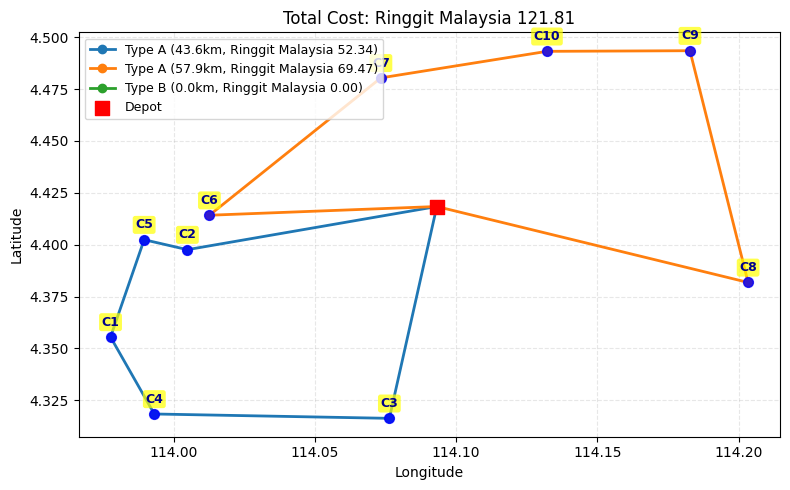

TOTAL DISTANCE : 101.51 km
TOTAL COST     : Ringgit Malaysia 121.81
Type A   |   43.6 km | Ringgit Malaysia  52.34 | Route: DEPOT → DEPOT → C2 → C5 → C1 → C4 → C3 → DEPOT
Type A   |   57.9 km | Ringgit Malaysia  69.47 | Route: DEPOT → DEPOT → C8 → C9 → C10 → C7 → C6 → DEPOT
Type B   |    0.0 km | Ringgit Malaysia   0.00 | Route: DEPOT → DEPOT → DEPOT


In [11]:
if solution:
    total_distance = 0
    total_cost = 0
    routes_data = []

    # === Extract all routes ===
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_nodes = []
        route_distance = 0
        route_load = 0
        load_history = [0]
        node_history = [0]

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data['demands'][node]
            load_history.append(route_load)
            node_history.append(node)

            prev_index = index
            index = solution.Value(routing.NextVar(index))
            arc_cost = routing.GetArcCostForVehicle(prev_index, index, vehicle_id)
            route_distance += arc_cost

        # Final return to depot
        node_history.append(0)
        load_history.append(0)

        cost_rm = (route_distance / 1000) * data['vehicle_costs_per_km'][vehicle_id]
        total_distance += route_distance
        total_cost += cost_rm

        routes_data.append({
            'vehicle_id': vehicle_id,
            'type': data['vehicle_types'][vehicle_id],
            'color': data['vehicle_colors'][vehicle_id],
            'nodes': node_history,
            'load': load_history,
            'distance_km': route_distance / 1000,
            'cost_rm': cost_rm
        })

    # === MAIN PLOT: Your exact figsize + your exact label style + C1..Cn annotations ===
    plt.figure(figsize=(8, 5))  # ← YOUR ORIGINAL SIZE

    # Plot routes
    for r in routes_data:
        lats = [locations[i][0] for i in r['nodes']]
        lons = [locations[i][1] for i in r['nodes']]
        plt.plot(lons, lats, 'o-', color=r['color'], linewidth=2, markersize=6,
                 label=f"{r['type']} ({r['distance_km']:.1f}km, Ringgit Malaysia {r['cost_rm']:.2f})")

    # Depot
    plt.scatter(depot_lon, depot_lat, c='red', s=100, marker='s', zorder=5, label='Depot')

    # All customers (gray background)
    plt.scatter(df['Longitude'], df['Latitude'], c='blue', alpha=0.8, s=50, zorder=4)

    # Annotate each customer as C1, C2, ..., Cn
    for idx, (lon, lat) in enumerate(zip(df['Longitude'], df['Latitude']), start=1):
        plt.annotate(f'C{idx}',
                     (lon, lat),
                     xytext=(0, 6),
                     textcoords='offset points',
                     fontsize=9,
                     fontweight='bold',
                     color='darkblue',
                     ha='center',
                     va='bottom',
                     bbox=dict(boxstyle="round,pad=0.2", facecolor='yellow', alpha=0.7, linewidth=0))

    # Your exact labels and style
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Total Cost: Ringgit Malaysia {total_cost:.2f}')
    plt.legend(fontsize=9, loc='upper left')
    plt.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # === Final summary (your exact format) ===
    print("="*60)
    print(f"TOTAL DISTANCE : {total_distance/1000:.2f} km")
    print(f"TOTAL COST     : Ringgit Malaysia {total_cost:.2f}")
    print("="*60)
    for r in routes_data:
        seq = " → ".join([f"C{n}" if n > 0 else "DEPOT" for n in r['nodes']])
        print(f"{r['type']:8} | {r['distance_km']:6.1f} km | Ringgit Malaysia {r['cost_rm']:6.2f} | Route: {seq}")

In [12]:
# Run Nearest Neighbor to compare against OR-Tools VRP solution
nn_routes, nn_distances, nn_loads = nearest_neighbor_solution(data, locations)

# Compute total
nn_total_distance = sum(nn_distances)
nn_total_cost = sum(
    (d / 1000) * data['vehicle_costs_per_km'][vid]
    for vid, d in enumerate(nn_distances)
)

# Extract routes_data for plotting
nn_routes_data = []
for vid, (route, dist, load) in enumerate(zip(nn_routes, nn_distances, nn_loads)):
    cost_rm = (dist / 1000) * data['vehicle_costs_per_km'][vid]
    nn_routes_data.append({
        'vehicle_id': vid,
        'type': data['vehicle_types'][vid],
        'color': data['vehicle_colors'][vid],
        'nodes': route,
        'distance_km': dist / 1000,
        'cost_rm': cost_rm,
        'load': load
    })

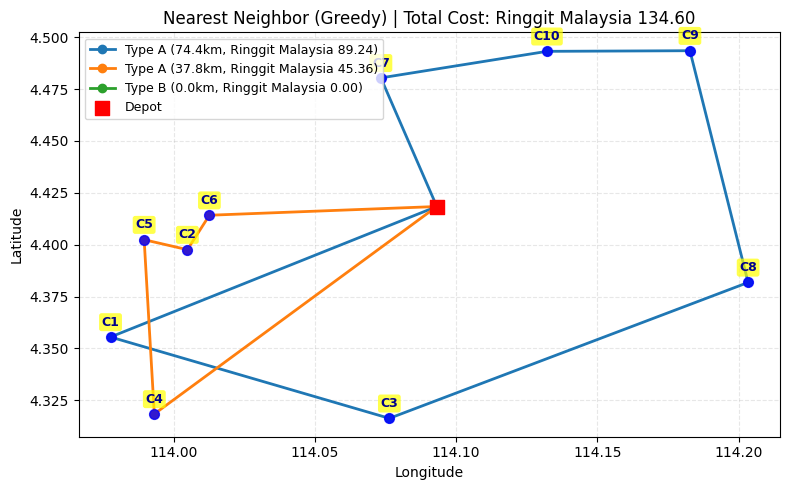

TOTAL DISTANCE : 112.17 km
TOTAL COST     : Ringgit Malaysia 134.60
Type A   |   74.4 km | Ringgit Malaysia  89.24 | Route: DEPOT → C7 → C10 → C9 → C8 → C3 → C1 → DEPOT
Type A   |   37.8 km | Ringgit Malaysia  45.36 | Route: DEPOT → C6 → C2 → C5 → C4 → DEPOT
Type B   |    0.0 km | Ringgit Malaysia   0.00 | Route: DEPOT → DEPOT


In [13]:
# Plot Nearest Neighbor solution
plt.figure(figsize=(8, 5))

for r in nn_routes_data:
    lats = [locations[i][0] for i in r['nodes']]
    lons = [locations[i][1] for i in r['nodes']]
    plt.plot(lons, lats, 'o-', color=r['color'], linewidth=2, markersize=6,
             label=f"{r['type']} ({r['distance_km']:.1f}km, Ringgit Malaysia {r['cost_rm']:.2f})")

# Depot
plt.scatter(depot_lon, depot_lat, c='red', s=100, marker='s', zorder=5, label='Depot')

# Customers
plt.scatter(df['Longitude'], df['Latitude'], c='blue', alpha=0.8, s=50, zorder=4)

# Annotate C1, C2, ..., Cn
for idx, (lon, lat) in enumerate(zip(df['Longitude'], df['Latitude']), start=1):
    plt.annotate(f'C{idx}',
                 (lon, lat),
                 xytext=(0, 6),
                 textcoords='offset points',
                 fontsize=9,
                 fontweight='bold',
                 color='darkblue',
                 ha='center',
                 va='bottom',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='yellow', alpha=0.7, linewidth=0))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Nearest Neighbor (Greedy) | Total Cost: Ringgit Malaysia {nn_total_cost:.2f}')
plt.legend(fontsize=9, loc='upper left')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# PRINT — EXACTLY LIKE YOUR VRP
# =====================================================
print("="*60)
print(f"TOTAL DISTANCE : {nn_total_distance/1000:.2f} km")
print(f"TOTAL COST     : Ringgit Malaysia {nn_total_cost:.2f}")
print("="*60)
for r in nn_routes_data:
    seq = " → ".join([f"C{n}" if n > 0 else "DEPOT" for n in r['nodes']])
    print(f"{r['type']:8} | {r['distance_km']:6.1f} km | Ringgit Malaysia {r['cost_rm']:6.2f} | Route: {seq}")
print("="*60)